In [1]:
import os
import time
import json
import pickle
import pandas as pd
import numpy as np
from functools import partial
import joblib

from datetime import datetime
from tqdm import tqdm
from dotenv import load_dotenv
from pathlib import Path

In [2]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import torch

import optuna
import mlflow
from databricks.sdk import WorkspaceClient

/opt/conda/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

Define path variables

In [4]:
representation_type = "traditional_word_BOW_absolute_difference"
developer_initials = "JP"

In [5]:
current_dir = Path.cwd()
env_path = current_dir.parent.parent / "conf" / "local" / ".env"
results_path = current_dir.parent.parent / "results" / "traditional"

train_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan20-authorship-verification-training-large-cleaned.jsonl"
validation_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan20-authorship-verification-validation-large-cleaned.jsonl"
test_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan21-authorship-verification-test-cleaned.jsonl"


Connect to databricks for logging results

In [6]:
load_dotenv(env_path)

w = WorkspaceClient()   
print("Connected to:", w.config.host)

mlflow.set_tracking_uri("databricks")
mlflow.autolog()

2025/12/22 23:02:31 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 1.4.0 <= scikit-learn, but the installed version is 1.3.2. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.


Connected to: https://dbc-1ea3ad0e-f504.cloud.databricks.com


2025/12/22 23:02:31 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/12/22 23:02:31 WARNING mlflow.utils.autologging_utils: MLflow statsmodels autologging is known to be compatible with 0.14.1 <= statsmodels, but the installed version is 0.14.0. If you encounter errors during autologging, try upgrading / downgrading statsmodels to a compatible version, or try upgrading MLflow.
2025/12/22 23:02:32 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2025/12/22 23:02:32 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.


In [7]:
mlflow.sklearn.autolog(disable=True)
mlflow.xgboost.autolog(disable=True)


What are GPU are the experiments run on

In [59]:
!nvidia-smi

Tue Dec 23 16:07:45 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:A3:00.0 Off |                    0 |
|  0%   37C    P8             35W /  300W |       3MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
running_on_gpu = torch.cuda.is_available()

In [10]:
if running_on_gpu:
    gpu_name = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_vram_gb = round(gpu_props.total_memory / (1024**3), 2)
else:
    gpu_name = "CPU"
    gpu_props = "N/A"
    gpu_vram_gb = 0

Empty the GPU from previous experiments

In [11]:
import gc
import torch
torch.cuda.empty_cache()
gc.collect()

69

In [12]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

Classification threshold constant specification

In [13]:
classification_thresholds = [x/1000 for x in range(200, 999)]

TF-IDF parameters for tuning

In [14]:
maximum_features = [20_000, 50_000, 100_000, None]
lowercase = [False, True]
minimum_df = (1e-5, 0.01)
maximum_df = (0.7, 1.0)
binary = [False, True]

# Load dataset

#### Load training data

In [15]:
train_data_file_size = os.path.getsize(train_data_full_cleaned_path)
train_data = []

with open(train_data_full_cleaned_path, 'r') as f:
    with tqdm(total=train_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            train_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(train_data)} items.")

Loading data: 100%|██████████| 11.3G/11.3G [02:03<00:00, 91.5MB/s]


Successfully loaded 273301 items.


In [16]:
train_data_df = pd.DataFrame(train_data)

Prepare dataset for cosine embedding loss

In [17]:
train_data_df.head(10)

,id,pair,same
0,e05b9c0b-88a1-5608-b7e8-ab1fc6b78dc1,"[Well, ever since you and Kurt broke up youve ...",False
1,12f73a20-cdf3-58df-b5bb-9392eec9b486,"[The thing is, Ryouga has no reason to run aft...",False
2,d82c6764-451b-544c-8711-c139e9349c56,"[Ehhhh nah, its silly' Its my job to listen to...",True
3,876b8380-9260-5427-93e8-dc31155c3edd,"[Glaring at the arrogant spark, Always asks va...",False
4,357e8471-35b9-50b4-9ac0-286ac0e8b101,[Runa limped across the small space to an open...,False
5,6b39fe22-409f-5329-9fe1-ddf4a70bedd1,"[And thats retired Commander, if you please St...",False
6,76ed2017-0c9f-580f-83b1-5a041a8169ec,[Meet you downstairs in twenty minutes I say w...,True
7,fd8deb2e-06de-5c92-9a4c-927891c53657,"[Since Ive seen so many others do so, Im going...",False
8,3ce5e811-a57c-5fbf-9f9a-2ee636e50be6,[party Eishi exclaimed Omi shook his head and ...,False
9,25a17cd2-6b01-5fba-99ef-e631e56e181d,[After a few moments she found that Red was ri...,False


#### Load validation data

In [18]:
val_data_file_size = os.path.getsize(validation_data_full_cleaned_path)
val_data = []

with open(validation_data_full_cleaned_path, 'r') as f:
    with tqdm(total=val_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            val_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(val_data)} items.")

Loading data: 100%|██████████| 103M/103M [00:01<00:00, 97.3MB/s] 


Successfully loaded 2500 items.


In [19]:
val_data_df = pd.DataFrame(val_data)

#### Load testing data

In [20]:
test_data_file_size = os.path.getsize(test_data_full_cleaned_path)
test_data = []

with open(test_data_full_cleaned_path, 'r') as f:
    with tqdm(total=test_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            test_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(test_data)} items.")

Loading data: 100%|██████████| 826M/826M [00:09<00:00, 89.8MB/s] 


Successfully loaded 19999 items.


In [21]:
test_data_df = pd.DataFrame(test_data)

# Extract features functions

Build vectorizer function

In [22]:
def build_bow_vectorizer(max_features, min_df, max_df, lowercase=True, binary=False):
    return CountVectorizer(
        analyzer="word",
        ngram_range=(1, 1),
        max_features=max_features,
        min_df=min_df,
        max_df=max_df,
        lowercase=lowercase,
        binary=binary
    )


Function to fit the vectorizer & return trasnformed training and testing pairs of texts - two tuples with two lists with pairs at the same index

In [23]:
def build_bow_features(vectorizer, train_df, test_df):
    train_texts1 = train_df["pair"].apply(lambda x: x[0])
    train_texts2 = train_df["pair"].apply(lambda x: x[1])
    test_texts1 = test_df["pair"].apply(lambda x: x[0])
    test_texts2 = test_df["pair"].apply(lambda x: x[1])
    
    print("Fitting vectorizer \n")
    vectorizer.fit(pd.concat([train_texts1, train_texts2]))

    print("Transforming texts with vectorizer\n")
    X_train1 = vectorizer.transform(train_texts1)
    X_train2 = vectorizer.transform(train_texts2)
    X_test1 = vectorizer.transform(test_texts1)
    X_test2 = vectorizer.transform(test_texts2)

    X_train = (X_train1, X_train2)
    X_test = (X_test1, X_test2)
    
    return X_train, X_test

Function to return the absolute difference of two lists of transformed text

In [24]:
def compute_absolute_difference_features(X_pair):
    X_1, X_2 = X_pair
    return abs(X_1 - X_2)

# Evaluation functions

Evaluation function

In [25]:
def evaluate_results(y_true, y_pred, average='binary'):
    accuracy = round(accuracy_score(y_true, y_pred)*100, 2)
    precision = round(precision_score(y_true, y_pred, average=average, zero_division=0)*100, 2)
    recall = round(recall_score(y_true, y_pred, average=average)*100, 2)
    f1 = round(f1_score(y_true, y_pred, average=average)*100, 2)
    return accuracy, precision, recall, f1

Create the confusion matrix

In [26]:
def plot_confusion_matrix(y_true, y_pred, model_id="", labels=[False, True]):

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        cbar=False
    )

    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix: {model_id}')

    plt.tight_layout()
    return fig

Create histogram of F1 score for different thresholds

In [27]:
def plot_f1_vs_threshold(results_df):
    plt.figure(figsize=(9, 5))
    plt.plot(results_df["threshold"], results_df["f1"], linewidth=2)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 Score vs Classification Threshold")
    plt.grid(True)
    plt.tight_layout()
    return plt.gcf()

# Classifier config setup for optuna studies

In [28]:
class ClassifierConfig: 
    def __init__(self, classifier_object, searched_hyperparameters, fixed_hyperparameters=None):
        self.classifier_object = classifier_object
        self.searched_hyperparameters = searched_hyperparameters or {}
        self.fixed_hyperparameters = fixed_hyperparameters or {}

    def sample_params(self, trial):
        sampled = {
            name: fn(trial)
            for name, fn in self.searched_hyperparameters.items()
        }
        sampled.update(self.fixed_hyperparameters)
        return sampled

# Optuna study function - for classifiers

In [29]:
def objective(trial, config):
    top_f1_trial = -1
    #get the vectorizer hyperparameters
    suggested_max_features = trial.suggest_categorical("max_features", maximum_features)
    suggested_min_df = trial.suggest_float("min_df", minimum_df[0], minimum_df[1])
    suggested_max_df =  trial.suggest_float("max_df", maximum_df[0], maximum_df[1])
    suggested_lowercase = trial.suggest_categorical("lowercase", lowercase)
    suggested_binary = trial.suggest_categorical("binary", binary)
    
    #get the classifier hyperparameters
    classifier_params = config.sample_params(trial)
    
    #set up vectorizer
    vectorizer = build_bow_vectorizer(
        max_features=suggested_max_features,
        min_df=suggested_min_df, 
        max_df=suggested_max_df,
        lowercase=suggested_lowercase,
        binary=suggested_binary
    )
    
    #set up classifier
    classifier = config.classifier_object(**classifier_params)

    #fit the vectorizer and create features of training and test data
    train_data, val_data = build_bow_features(vectorizer, train_data_df, val_data_df)

    #compute the absolute differences between the pairs of features in train and test data
    train_data_diff = compute_absolute_difference_features(train_data)
    val_data_diff = compute_absolute_difference_features(val_data)

    #get the labels for train and test data
    y_train = train_data_df["same"].values
    y_test = val_data_df["same"].values
    
    #Fit the classifier
    classifier.fit(train_data_diff, y_train)
    
    #predict the labels for the test data
    y_pred = classifier.predict(val_data_diff)
    
    top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

    print(f"Logging results \n")
    print(f"Top f1: {top_f1}\n")
    print(f"Top accuracy: { top_accuracy}\n")
    print(f"Top precision: {top_precision}\n")
    print(f"Top recall: {top_recall}\n")

    print(f"Used hyperparameters \n")
    print(f"max_features: {suggested_max_features}\n")
    print(f"min_df: {suggested_min_df}\n")
    print(f"max_df: {suggested_max_df}\n")
    print(f"lowercase: {suggested_lowercase}\n")
    print(f"binary: {suggested_binary}\n")
    

    trial.set_user_attr(
    "results",
    {
    "metrics": {
        "top_f1": top_f1,
        "top_accuracy": top_accuracy,
        "top_precision": top_precision,
        "top_recall": top_recall
        },
    "hyperparameters": {
        "max_features": suggested_max_features,
        "min_df": suggested_min_df,
        "max_df": suggested_max_df,
        "lowercase": suggested_lowercase,
        "binary": suggested_binary
        },
    "classifier_hyperparameters": {
            **classifier_params
        },
    }
    )
    print(classifier_params)
    del train_data, val_data, vectorizer, classifier

    return top_f1   

# Evaluate model hyperparameters - Multinomial naïve Bayes

In [ ]:
classifier_name = "multinomial_naive_bayes"

In [ ]:
multinomial_naive_bayes_config = ClassifierConfig(
    classifier_object=MultinomialNB,
    searched_hyperparameters={
        "alpha": lambda trial: trial.suggest_float("alpha", 1e-3, 1.0, log=True)
    },
    fixed_hyperparameters={}
)

Set up the study

In [ ]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

In [ ]:
study.optimize(lambda trial: objective(trial, multinomial_naive_bayes_config), n_trials=17)

Save the study insights

In [ ]:
best_trial = study.best_trial
best_params = best_trial.params

date_str = datetime.now().strftime("%Y%m%d_%H%M")

trial_results_path = current_dir.parent.parent / "data" / "02_models" / "traditional" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_vectorizer_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_vectorizer.pkl"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [ ]:
trial_rows = []

for trial in study.trials:
    
    metrics = trial.user_attrs["results"]["metrics"]
    hyper_params = trial.user_attrs["results"]["hyperparameters"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in hyper_params.items()},
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

In [ ]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [ ]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - Multinomial naïve Bayes

In [ ]:
best_params = {}
trial_results = {}

In [ ]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [ ]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [ ]:
trial_results_df = pd.DataFrame(trial_results)

In [ ]:
top_max_features = best_params["max_features"]
top_min_df = best_params["min_df"]
top_max_df =  best_params["max_df"]
top_lowercase = best_params["lowercase"]
top_binary = best_params["binary"]
top_alpha = best_params["alpha"]

In [ ]:
print(f"Used hyperparameters \n")
print(f"max_features: {top_max_features}\n")
print(f"min_df: {top_min_df}\n")
print(f"max_df: {top_max_df}\n")
print(f"lowercase: {top_lowercase}\n")
print(f"binary: {top_binary}\n")
print(f"alpha: {top_alpha}\n")

Reconstruct the best vectorizer

In [ ]:
best_vectorizer = build_bow_vectorizer(
        max_features=top_max_features,
        min_df=top_min_df, 
        max_df=top_max_df,
        lowercase=top_lowercase,
        binary=top_binary
    )

Combine validation and training dataset

In [ ]:
final_train_df = pd.concat(
    [train_data_df, val_data_df],
    ignore_index=True
)

Fit the vectorizer and create features of training and test data

In [ ]:
train_data, test_data = build_bow_features(best_vectorizer, final_train_df, test_data_df)

Compute the absolute differences between the pairs of features in train and test data

In [ ]:
train_data_diff = compute_absolute_difference_features(train_data)
test_data_diff = compute_absolute_difference_features(test_data)

Get the labels for train and test data

In [ ]:
y_train = final_train_df["same"].values
y_test = test_data_df["same"].values

Fit the classifier

In [ ]:
classifier = MultinomialNB(alpha=top_alpha)
classifier.fit(train_data_diff, y_train)

Predict the labels for the test data

In [ ]:
y_pred = classifier.predict(test_data_diff)

Evaluate the results of the final classifier

In [ ]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Save the final vectorizer and classifier

In [ ]:
joblib.dump(best_vectorizer, finetuned_vectorizer_path)
joblib.dump(classifier, finetuned_model_path)

Confusion matrix

In [ ]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [ ]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
    
    mlflow.log_param("max_features", top_max_features)
    mlflow.log_param("min_df", top_min_df)
    mlflow.log_param("max_df", top_max_df)
    mlflow.log_param("lowercase", top_lowercase)
    mlflow.log_param("binary", top_binary)
    mlflow.log_param("alpha", top_alpha)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

# Evaluate model hyperparameters - Logistic regression

In [30]:
classifier_name = "logistic_regression"

Resolving the penalty parameter - for both types only certain solvers are possible

In [31]:
logistic_regression_config = ClassifierConfig(
    classifier_object=LogisticRegression,
    searched_hyperparameters={
        "C": lambda trial: trial.suggest_float("C", 0.01, 5.0, log=True),
        "penalty": lambda trial: trial.suggest_categorical("penalty", ["l1", "l2"]),
        "solver": lambda trial: trial.suggest_categorical("solver", ["liblinear", "saga"]),
    },
    fixed_hyperparameters={
        "max_iter": 5000,
        "n_jobs": -1 #uses all cores
    }
)

Set up the study

In [32]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)



[I 2025-12-20 13:33:57,250] Using an existing study with name 'authorship_verification_traditional_word_BOW_absolute_difference_logistic_regression' instead of creating a new one.


In [33]:
len(study.trials)

24

In [34]:
study.optimize(lambda trial: objective(trial, logistic_regression_config), n_trials=30-len(study.trials))

Fitting vectorizer 

Transforming texts with vectorizer



/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1223: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(


Logging results 

Top f1: 87.84

Top accuracy: 88.86

Top precision: 88.33

Top recall: 88.6

Used hyperparameters 

max_features: 100000

min_df: 0.007333269661346925

max_df: 0.8698001068574136

lowercase: True

binary: True

{'C': 0.03493957533614682, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 5000, 'n_jobs': -1}


[I 2025-12-20 14:17:41,543] Trial 24 finished with value: 87.84 and parameters: {'max_features': 100000, 'min_df': 0.007333269661346925, 'max_df': 0.8698001068574136, 'lowercase': True, 'binary': True, 'C': 0.03493957533614682, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 15 with value: 87.96.


Fitting vectorizer 

Transforming texts with vectorizer



...

[I 2025-12-20 17:38:15,789] Trial 28 finished with value: 87.56 and parameters: {'max_features': None, 'min_df': 0.003109654477496762, 'max_df': 0.7886901183030616, 'lowercase': True, 'binary': True, 'C': 0.026589888945320134, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 15 with value: 87.96.


Fitting vectorizer 

Transforming texts with vectorizer



/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1223: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(


Logging results 

Top f1: 87.96

Top accuracy: 88.95

Top precision: 88.48

Top recall: 88.71

Used hyperparameters 

max_features: 50000

min_df: 0.008243551655520862

max_df: 0.9093324343133575

lowercase: True

binary: True

{'C': 0.05851977257335507, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 5000, 'n_jobs': -1}


[I 2025-12-20 18:23:34,425] Trial 29 finished with value: 87.96 and parameters: {'max_features': 50000, 'min_df': 0.008243551655520862, 'max_df': 0.9093324343133575, 'lowercase': True, 'binary': True, 'C': 0.05851977257335507, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 15 with value: 87.96.


Save the study insights

In [35]:
best_trial = study.best_trial
best_params = best_trial.params
best_params.update({
    "max_iter": 5000,
    "n_jobs": -1
})

In [36]:
date_str = datetime.now().strftime("%Y%m%d_%H%M")

trial_results_path = current_dir.parent.parent / "data" / "02_models" / "traditional" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_vectorizer_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_vectorizer.pkl"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [37]:
trial_rows = []

for trial in study.trials:
    
    if "results" not in trial.user_attrs:
        continue 
        
    metrics = trial.user_attrs["results"]["metrics"]
    hyper_params = trial.user_attrs["results"]["hyperparameters"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in hyper_params.items()},
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

,trial_number,top_f1,top_accuracy,top_precision,top_recall,max_features,min_df,max_df,lowercase,binary,C,penalty,solver,max_iter,n_jobs
0,0,86.08,87.43,86.39,86.91,50000.0,0.001031,0.828815,True,True,0.417198,l2,liblinear,5000,-1
1,1,83.64,84.73,84.67,84.70,100000.0,0.002856,0.827122,True,True,1.727981,l1,saga,5000,-1
2,2,87.08,88.12,87.66,87.89,20000.0,0.006884,0.972516,True,True,0.015112,l1,liblinear,5000,-1
3,3,82.96,84.17,83.92,84.04,50000.0,0.005871,0.926160,False,True,1.864691,l1,saga,5000,-1
4,4,77.72,78.38,80.55,79.45,NaN,0.006036,0.738104,False,False,0.085841,l2,saga,5000,-1


In [38]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [39]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - Logistic regression

In [40]:
best_params = {}
trial_results = {}

In [41]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [42]:
print(best_params)

{'max_features': 100000, 'min_df': 0.008013556828423583, 'max_df': 0.8798511815502209, 'lowercase': True, 'binary': True, 'C': 0.05245089790299418, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 5000, 'n_jobs': -1}


In [43]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [44]:
trial_results_df = pd.DataFrame(trial_results)

In [45]:
top_max_features = best_params["max_features"]
top_min_df = best_params["min_df"]
top_max_df =  best_params["max_df"]
top_lowercase = best_params["lowercase"]
top_binary = best_params["binary"]
top_c = best_params["C"]
top_penalty = best_params["penalty"]
top_solver = best_params["solver"]
top_max_iter = best_params["max_iter"]
top_n_jobs = best_params["n_jobs"]

In [46]:
print(f"Used hyperparameters \n")
print(f"max_features: {top_max_features}\n")
print(f"min_df: {top_min_df}\n")
print(f"max_df: {top_max_df}\n")
print(f"lowercase: {top_lowercase}\n")
print(f"binary: {top_binary}\n")
print(f"c: {top_c}\n")
print(f"penalty: {top_penalty}\n")
print(f"solver: {top_solver}\n")
print(f"max_iter: {top_max_iter}\n")
print(f"n_jobs: {top_n_jobs}\n")

Used hyperparameters 

max_features: 100000

min_df: 0.008013556828423583

max_df: 0.8798511815502209

lowercase: True

binary: True

c: 0.05245089790299418

penalty: l1

solver: liblinear

max_iter: 5000

n_jobs: -1



Reconstruct the best vectorizer

In [47]:
best_vectorizer = build_bow_vectorizer(
        max_features=top_max_features,
        min_df=top_min_df, 
        max_df=top_max_df,
        lowercase=top_lowercase,
        binary=top_binary
    )

Combine validation and training dataset

In [48]:
final_train_df = pd.concat(
    [train_data_df, val_data_df],
    ignore_index=True
)

Fit the vectorizer and create features of training and test data

In [49]:
train_data, test_data = build_bow_features(best_vectorizer, final_train_df, test_data_df)

Fitting vectorizer 

Transforming texts with vectorizer



Compute the absolute differences between the pairs of features in train and test data

In [50]:
train_data_diff = compute_absolute_difference_features(train_data)
test_data_diff = compute_absolute_difference_features(test_data)

Get the labels for train and test data

In [51]:
y_train = final_train_df["same"].values
y_test = test_data_df["same"].values

Fit the classifier

In [52]:
classifier = LogisticRegression(
    C=top_c,
    penalty=top_penalty,
    solver=top_solver,
    max_iter=top_max_iter,
    n_jobs=top_n_jobs
)
classifier.fit(train_data_diff, y_train)

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1223: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(


LogisticRegression(C=0.05245089790299418, max_iter=5000, n_jobs=-1,
                   penalty='l1', solver='liblinear')

Predict the labels for the test data

In [53]:
y_pred = classifier.predict(test_data_diff)

Evaluate the results of the final classifier

In [54]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Logging results 

Top f1: 88.91

Top accuracy: 90.21

Top precision: 87.29

Top recall: 88.73



Save the final vectorizer and classifier

In [55]:
joblib.dump(best_vectorizer, finetuned_vectorizer_path)
joblib.dump(classifier, finetuned_model_path)

['/home/jovyan/authorship_verification_dt/data/02_models/traditional/JP_traditional_word_BOW_absolute_difference_logistic_regression_best_model.pkl']

Confusion matrix

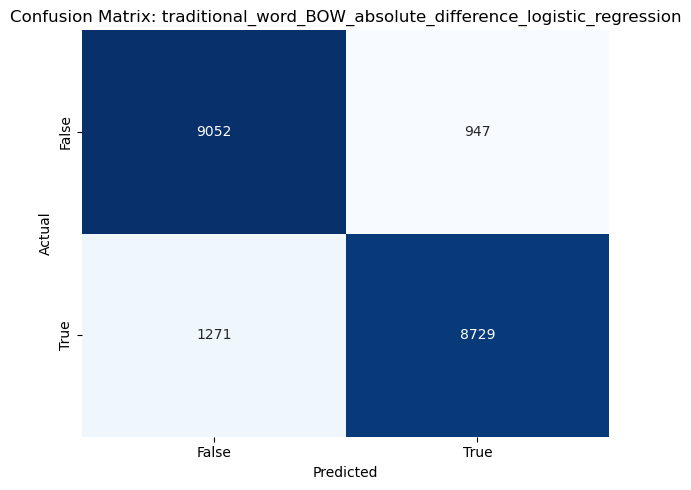

In [56]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [57]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier_name}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
    
    mlflow.log_param("max_features", top_max_features)
    mlflow.log_param("min_df", top_min_df)
    mlflow.log_param("max_df", top_max_df)
    mlflow.log_param("lowercase", top_lowercase)
    mlflow.log_param("binary", top_binary)
    mlflow.log_param("C", top_c)
    mlflow.log_param("penalty", top_penalty)
    mlflow.log_param("solver", top_solver)
    mlflow.log_param("max_iter", top_max_iter)
    mlflow.log_param("n_jobs", top_n_jobs)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_traditional_word_BOW_absolute_difference_logistic_regression at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/0b59d4e809e14bdcbd9f7bbe0eff41f7
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040


# Evaluate model hyperparameters - Linear SVC

In [58]:
classifier_name = "linear_svc"

In [59]:
linear_svc_config = ClassifierConfig(
    classifier_object=LinearSVC,
    searched_hyperparameters={
        "C": lambda trial: trial.suggest_float("C", 0.01, 5.0, log=True),
        "loss": lambda trial: trial.suggest_categorical("loss", ["hinge", "squared_hinge"]),
        "class_weight": lambda trial: trial.suggest_categorical("class_weight", [None, "balanced"]),
    },
    fixed_hyperparameters={
        "penalty": "l2",       # LinearSVC ONLY supports l2
        "dual": True,          # for high-dimensional data (TF-IDF)
        "max_iter": 5000       # ensure convergence
    }
)

Set up the study

In [60]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-20 19:10:11,621] A new study created in RDB with name: authorship_verification_traditional_word_BOW_absolute_difference_linear_svc


In [ ]:
study.optimize(lambda trial: objective(trial, linear_svc_config), n_trials=30)

Fitting vectorizer 

Transforming texts with vectorizer

Logging results 

Top f1: 86.48

Top accuracy: 88.81

Top precision: 85.49

Top recall: 87.12

Used hyperparameters 

max_features: 50000

min_df: 0.006438058226543342

max_df: 0.7569799046380624

lowercase: True

binary: True

{'C': 0.04080240382661624, 'loss': 'squared_hinge', 'class_weight': 'balanced', 'penalty': 'l2', 'dual': True, 'max_iter': 5000}


[I 2025-12-20 19:55:42,704] Trial 0 finished with value: 86.48 and parameters: {'max_features': 50000, 'min_df': 0.006438058226543342, 'max_df': 0.7569799046380624, 'lowercase': True, 'binary': True, 'C': 0.04080240382661624, 'loss': 'squared_hinge', 'class_weight': 'balanced'}. Best is trial 0 with value: 86.48.


Fitting vectorizer 

Transforming texts with vectorizer



/opt/conda/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Logging results 

Top f1: 80.64

Top accuracy: 78.34

Top precision: 88.18

Top recall: 82.97

Used hyperparameters 

max_features: 50000

min_df: 0.006983241032682559

max_df: 0.9618717071712279

lowercase: False

binary: False

{'C': 0.29405417410777673, 'loss': 'squared_hinge', 'class_weight': 'balanced', 'penalty': 'l2', 'dual': True, 'max_iter': 5000}


...

Fitting vectorizer 

Transforming texts with vectorizer



/opt/conda/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Logging results 

Top f1: 79.36

Top accuracy: 90.6

Top precision: 68.51

Top recall: 78.02

Used hyperparameters 

max_features: 20000

min_df: 0.0018501203495248347

max_df: 0.9943211577518892

lowercase: True

binary: False

{'C': 1.3925932406789476, 'loss': 'squared_hinge', 'class_weight': None, 'penalty': 'l2', 'dual': True, 'max_iter': 5000}


[I 2025-12-21 07:02:55,555] Trial 8 finished with value: 79.36 and parameters: {'max_features': 20000, 'min_df': 0.0018501203495248347, 'max_df': 0.9943211577518892, 'lowercase': True, 'binary': False, 'C': 1.3925932406789476, 'loss': 'squared_hinge', 'class_weight': None}. Best is trial 3 with value: 86.8.


Fitting vectorizer 



Save the study insights

In [ ]:
best_trial = study.best_trial
best_params = best_trial.params
best_params.update({
    "penalty": "l2",       
    "dual": True,          
    "max_iter": 5000
})


In [ ]:
trial_results_path = current_dir.parent.parent / "data" / "02_models" / "traditional" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_vectorizer_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_vectorizer.pkl"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [ ]:
trial_rows = []

for trial in study.trials:
    
    if "results" not in trial.user_attrs:
        continue 
        
    metrics = trial.user_attrs["results"]["metrics"]
    hyper_params = trial.user_attrs["results"]["hyperparameters"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in hyper_params.items()},
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

In [ ]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [ ]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - Linear SVC

In [ ]:
best_params = {}
trial_results = {}

In [ ]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [ ]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [ ]:
trial_results_df = pd.DataFrame(trial_results)

In [ ]:
top_max_features = best_params["max_features"]
top_min_df = best_params["min_df"]
top_max_df =  best_params["max_df"]
top_lowercase = best_params["lowercase"]
top_binary = best_params["binary"]

top_c = best_params["C"]
top_loss = best_params["loss"]
top_class_weight = best_params["class_weight"]
top_penalty = best_params["penalty"]
top_dual = best_params["dual"]
top_max_iter = best_params["max_iter"]

In [ ]:
print(f"Used hyperparameters \n")
print(f"max_features: {top_max_features}\n")
print(f"min_df: {top_min_df}\n")
print(f"max_df: {top_max_df}\n")
print(f"lowercase: {top_lowercase}\n")
print(f"binary: {top_binary}\n")

print(f"c: {top_c}\n")
print(f"loss: {top_loss}\n")
print(f"class_weight: {top_class_weight}\n")
print(f"penalty: {top_penalty}\n")
print(f"dual: {top_dual}\n")
print(f"max_iter: {top_max_iter}\n")

Reconstruct the best vectorizer

In [ ]:
best_vectorizer = build_bow_vectorizer(
        max_features=top_max_features,
        min_df=top_min_df, 
        max_df=top_max_df,
        lowercase=top_lowercase,
        binary=top_binary
    )

Combine validation and training dataset

In [ ]:
final_train_df = pd.concat(
    [train_data_df, val_data_df],
    ignore_index=True
)

Fit the vectorizer and create features of training and test data

In [ ]:
train_data, test_data = build_bow_features(best_vectorizer, final_train_df, test_data_df)

Compute the absolute differences between the pairs of features in train and test data

In [ ]:
train_data_diff = compute_absolute_difference_features(train_data)
test_data_diff = compute_absolute_difference_features(test_data)

Get the labels for train and test data

In [ ]:
y_train = final_train_df["same"].values
y_test = test_data_df["same"].values

Fit the classifier

In [ ]:
classifier = LinearSVC(
    C=top_c,
    loss=top_loss,
    class_weight=top_class_weight,
    penalty=top_penalty,
    dual=top_dual,
    max_iter=top_max_iter
)

classifier.fit(train_data_diff, y_train)

Predict the labels for the test data

In [ ]:
y_pred = classifier.predict(test_data_diff)

Evaluate the results of the final classifier

In [ ]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Save the final vectorizer and classifier

In [ ]:
joblib.dump(best_vectorizer, finetuned_vectorizer_path)
joblib.dump(classifier, finetuned_model_path)

Confusion matrix

In [ ]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [ ]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier_name}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
    
    mlflow.log_param("max_features", top_max_features)
    mlflow.log_param("min_df", top_min_df)
    mlflow.log_param("max_df", top_max_df)
    mlflow.log_param("lowercase", top_lowercase)
    mlflow.log_param("binary", top_binary)
                    
    mlflow.log_param("C", top_c)
    mlflow.log_param("loss", top_loss)
    mlflow.log_param("class_weight", top_class_weight)
    mlflow.log_param("penalty", top_penalty)
    mlflow.log_param("dual", top_dual)
    mlflow.log_param("max_iter", top_max_iter)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

# Evaluate model hyperparameters - K-nearest neighbors

In [30]:
classifier_name = "k-nearest_neighbors"

In [31]:
knn_config = ClassifierConfig(
    classifier_object=KNeighborsClassifier,
    searched_hyperparameters={
        "n_neighbors": lambda trial: trial.suggest_int("n_neighbors", 1, 50),
        "weights": lambda trial: trial.suggest_categorical("weights", ["uniform", "distance"]),
        "metric": lambda trial: trial.suggest_categorical("metric", ["euclidean", "manhattan", "cosine"]),
    },
    fixed_hyperparameters={
        "algorithm": "auto"
    }
)

Set up the study

In [32]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-22 23:04:48,501] Using an existing study with name 'authorship_verification_traditional_word_BOW_absolute_difference_k-nearest_neighbors' instead of creating a new one.


In [33]:
len(study.trials)

14

In [36]:
study.optimize(lambda trial: objective(trial, knn_config), n_trials=30-len(study.trials), n_jobs=2, show_progress_bar=True)

  0%|          | 0/14 [00:00<?, ?it/s]

Fitting vectorizer 

Fitting vectorizer 



--- Logging error ---


Transforming texts with vectorizer
[W 2025-12-23 00:46:18,235] Trial 15 failed with parameters: {'max_features': 50000, 'min_df': 0.002930675962253844, 'max_df': 0.7153890042005607, 'lowercase': False, 'binary': False, 'n_neighbors': 2, 'weights': 'distance', 'metric': 'cosine'} because of the following error: ZMQError('Socket operation on non-socket').
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_394/2075450777.py", line 1, in <lambda>
    study.optimize(lambda trial: objective(trial, knn_config), n_trials=30, n_jobs=2, show_progress_bar=True)
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_394/3853560746.py", line 26, in objective
    train_data, val_data = build_bow_features(vectorizer, train_data_df, val_data_df)
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Save the study insights

In [37]:
best_trial = study.best_trial
best_params = best_trial.params

best_trial = study.best_trial
best_params = best_trial.params
best_params.update({
    "algorithm": "auto"
})

In [38]:
trial_results_path = current_dir.parent.parent / "data" / "02_models" / "traditional" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_vectorizer_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_vectorizer.pkl"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [39]:
trial_rows = []

for trial in study.trials:
    
    if "results" not in trial.user_attrs:
        continue 
        
    metrics = trial.user_attrs["results"]["metrics"]
    hyper_params = trial.user_attrs["results"]["hyperparameters"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in hyper_params.items()},
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

,trial_number,top_f1,top_accuracy,top_precision,top_recall,max_features,min_df,max_df,lowercase,binary,n_neighbors,weights,metric,algorithm
0,0,49.16,100.00,4.94,9.41,20000.0,0.001121,0.815076,True,True,37,distance,cosine,auto
1,1,58.40,56.38,98.13,71.62,100000.0,0.008803,0.915918,False,False,10,distance,euclidean,auto
2,2,51.40,100.00,9.12,16.72,20000.0,0.007076,0.862045,False,True,33,distance,cosine,auto
3,3,53.48,53.48,100.00,69.69,50000.0,0.006701,0.911851,True,True,45,distance,manhattan,auto
4,4,53.48,53.48,100.00,69.69,50000.0,0.005403,0.878212,True,True,10,uniform,manhattan,auto


In [40]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [41]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - K-nearest neighbors

In [42]:
best_params = {}
trial_results = {}

In [43]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [44]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [45]:
trial_results_df = pd.DataFrame(trial_results)

In [46]:
top_max_features = best_params["max_features"]
top_min_df = best_params["min_df"]
top_max_df =  best_params["max_df"]
top_lowercase = best_params["lowercase"]
top_binary = best_params["binary"]

top_n_neighbors = best_params["n_neighbors"]
top_weights = best_params["weights"]
top_metric = best_params["metric"]
top_algorithm = best_params["algorithm"]

In [47]:
print(f"Used hyperparameters \n")
print(f"max_features: {top_max_features}\n")
print(f"min_df: {top_min_df}\n")
print(f"max_df: {top_max_df}\n")
print(f"lowercase: {top_lowercase}\n")
print(f"binary: {top_binary}\n")

print(f"n_neighbors: {top_n_neighbors}\n")
print(f"weights: {top_weights}\n")
print(f"metric: {top_metric}\n")
print(f"algorithm: {top_algorithm}\n")

Used hyperparameters 

max_features: 50000

min_df: 0.004135132901886645

max_df: 0.7339091926540919

lowercase: False

binary: False

n_neighbors: 1

weights: distance

metric: cosine

algorithm: auto



Reconstruct the best vectorizer

In [48]:
best_vectorizer = build_bow_vectorizer(
        max_features=top_max_features,
        min_df=top_min_df, 
        max_df=top_max_df,
        lowercase=top_lowercase,
        binary=top_binary
    )

Combine validation and training dataset

In [49]:
final_train_df = pd.concat(
    [train_data_df, val_data_df],
    ignore_index=True
)

Fit the vectorizer and create features of training and test data

In [50]:
train_data, test_data = build_bow_features(best_vectorizer, final_train_df, test_data_df)

Fitting vectorizer 

Transforming texts with vectorizer



Compute the absolute differences between the pairs of features in train and test data

In [51]:
train_data_diff = compute_absolute_difference_features(train_data)
test_data_diff = compute_absolute_difference_features(test_data)

Get the labels for train and test data

In [52]:
y_train = final_train_df["same"].values
y_test = test_data_df["same"].values

Fit the classifier

In [53]:
classifier = KNeighborsClassifier(
    n_neighbors=top_n_neighbors,
    weights=top_weights,
    metric=top_metric,
    algorithm=top_algorithm
)

classifier.fit(train_data_diff, y_train)

KNeighborsClassifier(metric='cosine', n_neighbors=1, weights='distance')

Predict the labels for the test data

In [54]:
y_pred = classifier.predict(test_data_diff)

Evaluate the results of the final classifier

In [55]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Logging results 

Top f1: 52.51

Top accuracy: 53.43

Top precision: 39.14

Top recall: 45.18



Save the final vectorizer and classifier

In [56]:
joblib.dump(best_vectorizer, finetuned_vectorizer_path)
joblib.dump(classifier, finetuned_model_path)

['/home/jovyan/authorship_verification_dt/data/02_models/traditional/JP_traditional_word_BOW_absolute_difference_k-nearest_neighbors_best_model.pkl']

Confusion matrix

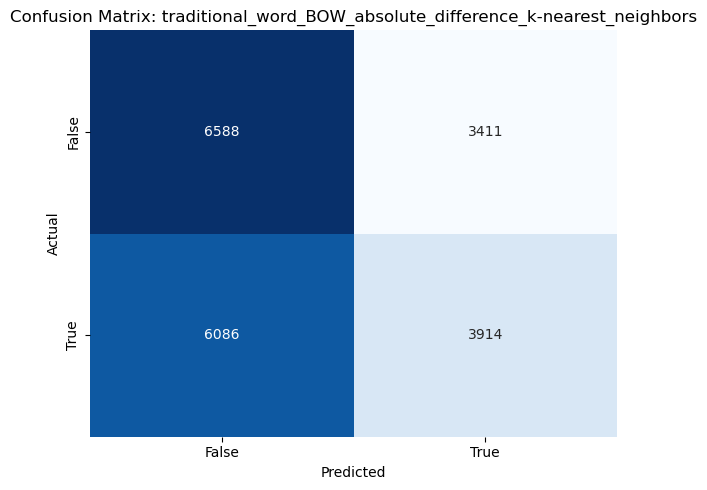

In [57]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [58]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier_name}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
    
    mlflow.log_param("max_features", top_max_features)
    mlflow.log_param("min_df", top_min_df)
    mlflow.log_param("max_df", top_max_df)
    mlflow.log_param("lowercase", top_lowercase)
    mlflow.log_param("binary", top_binary)
                    
    mlflow.log_param("n_neighbors", top_n_neighbors)
    mlflow.log_param("weights", top_weights)
    mlflow.log_param("metric", top_metric)
    mlflow.log_param("algorithm", top_algorithm)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_traditional_word_BOW_absolute_difference_k-nearest_neighbors at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/0a6f7abaf9704d878ea0b92db5c538d4
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040


# Evaluate model hyperparameters - Random Forest

In [30]:
classifier_name = "random_forest"

In [31]:
random_forest_config = ClassifierConfig(
    classifier_object=RandomForestClassifier,
    searched_hyperparameters={
        "n_estimators": lambda trial: trial.suggest_int("n_estimators", 100, 600),
        "max_depth": lambda trial: trial.suggest_int("max_depth", 5, 50),
        "min_samples_split": lambda trial: trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": lambda trial: trial.suggest_int("min_samples_leaf", 1, 10)
    },
    fixed_hyperparameters={
        "n_jobs": -1,        # use all cores
        "random_state": 42   # reproducible forests
    }
)

Set up the study

In [32]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-21 07:12:51,378] A new study created in RDB with name: authorship_verification_traditional_word_BOW_absolute_difference_random_forest


In [33]:
study.optimize(lambda trial: objective(trial, random_forest_config), n_trials=30)

Fitting vectorizer 

Transforming texts with vectorizer

Logging results 

Top f1: 79.32

Top accuracy: 74.82

Top precision: 92.45

Top recall: 82.7

Used hyperparameters 

max_features: 20000

min_df: 0.0022193830216626926

max_df: 0.8671609848261277

lowercase: False

binary: True

{'n_estimators': 546, 'max_depth': 45, 'min_samples_split': 10, 'min_samples_leaf': 6, 'n_jobs': -1, 'random_state': 42}


[I 2025-12-21 08:22:26,803] Trial 0 finished with value: 79.32 and parameters: {'max_features': 20000, 'min_df': 0.0022193830216626926, 'max_df': 0.8671609848261277, 'lowercase': False, 'binary': True, 'n_estimators': 546, 'max_depth': 45, 'min_samples_split': 10, 'min_samples_leaf': 6}. Best is trial 0 with value: 79.32.


Fitting vectorizer 

Transforming texts with vectorizer

Logging results 

Top f1: 79.32

Top accuracy: 74.29

Top precision: 93.79

Top recall: 82.91

Used hyperparameters 

max_features: None

min_df: 0.0010850267264869116

max_df: 0.9094554829246634

lowercase: True

binary: True

{'n_estimators': 520, 'max_depth': 24, 'min_samples_split': 7, 'min_samples_leaf': 6, 'n_jobs': -1, 'random_state': 42}


[I 2025-12-21 09:17:37,392] Trial 1 finished with value: 79.32 and parameters: {'max_features': None, 'min_df': 0.0010850267264869116, 'max_df': 0.9094554829246634, 'lowercase': True, 'binary': True, 'n_estimators': 520, 'max_depth': 24, 'min_samples_split': 7, 'min_samples_leaf': 6}. Best is trial 0 with value: 79.32.


Fitting vectorizer 

Transforming texts with vectorizer

Logging results 

Top f1: 76.76

Top accuracy: 74.05

Top precision: 87.06

Top recall: 80.03

Used hyperparameters 

max_features: 20000

min_df: 0.0010207771424656925

max_df: 0.8656967486503268

lowercase: False

binary: False

{'n_estimators': 289, 'max_depth': 42, 'min_samples_split': 12, 'min_samples_leaf': 3, 'n_jobs': -1, 'random_state': 42}


...

[I 2025-12-22 11:30:08,627] Trial 27 finished with value: 80.32 and parameters: {'max_features': 100000, 'min_df': 0.008694893502955154, 'max_df': 0.8129721656427096, 'lowercase': True, 'binary': True, 'n_estimators': 492, 'max_depth': 37, 'min_samples_split': 3, 'min_samples_leaf': 3}. Best is trial 27 with value: 80.32.


Fitting vectorizer 

Transforming texts with vectorizer

Logging results 

Top f1: 80.28

Top accuracy: 76.54

Top precision: 91.02

Top recall: 83.16

Used hyperparameters 

max_features: 100000

min_df: 0.009994744554282967

max_df: 0.8036213956949071

lowercase: True

binary: True

{'n_estimators': 493, 'max_depth': 42, 'min_samples_split': 4, 'min_samples_leaf': 3, 'n_jobs': -1, 'random_state': 42}


[I 2025-12-22 12:49:09,065] Trial 28 finished with value: 80.28 and parameters: {'max_features': 100000, 'min_df': 0.009994744554282967, 'max_df': 0.8036213956949071, 'lowercase': True, 'binary': True, 'n_estimators': 493, 'max_depth': 42, 'min_samples_split': 4, 'min_samples_leaf': 3}. Best is trial 27 with value: 80.32.


Fitting vectorizer 

Transforming texts with vectorizer

Logging results 

Top f1: 80.32

Top accuracy: 76.36

Top precision: 91.55

Top recall: 83.27

Used hyperparameters 

max_features: 100000

min_df: 0.00996019093014342

max_df: 0.8233359425794089

lowercase: True

binary: True

{'n_estimators': 556, 'max_depth': 42, 'min_samples_split': 13, 'min_samples_leaf': 5, 'n_jobs': -1, 'random_state': 42}


[I 2025-12-22 14:01:08,183] Trial 29 finished with value: 80.32 and parameters: {'max_features': 100000, 'min_df': 0.00996019093014342, 'max_df': 0.8233359425794089, 'lowercase': True, 'binary': True, 'n_estimators': 556, 'max_depth': 42, 'min_samples_split': 13, 'min_samples_leaf': 5}. Best is trial 27 with value: 80.32.


Save the study insights

In [34]:
best_trial = study.best_trial
best_params = best_trial.params
best_params.update({
    "n_jobs": -1,        
    "random_state": 42   
})


In [35]:
trial_results_path = current_dir.parent.parent / "data" / "02_models" / "traditional" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_vectorizer_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_vectorizer.pkl"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [36]:
trial_rows = []

for trial in study.trials:
    
    if "results" not in trial.user_attrs:
        continue 
        
    metrics = trial.user_attrs["results"]["metrics"]
    hyper_params = trial.user_attrs["results"]["hyperparameters"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in hyper_params.items()},
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

,trial_number,top_f1,top_accuracy,top_precision,top_recall,max_features,min_df,max_df,lowercase,binary,n_estimators,max_depth,min_samples_split,min_samples_leaf,n_jobs,random_state
0,0,79.32,74.82,92.45,82.70,20000.0,0.002219,0.867161,False,True,546,45,10,6,-1,42
1,1,79.32,74.29,93.79,82.91,NaN,0.001085,0.909455,True,True,520,24,7,6,-1,42
2,2,76.76,74.05,87.06,80.03,20000.0,0.001021,0.865697,False,False,289,42,12,3,-1,42
3,3,77.20,73.78,89.01,80.68,100000.0,0.001387,0.904029,False,False,448,45,15,5,-1,42
4,4,75.88,72.19,89.30,79.84,NaN,0.000769,0.854525,False,False,146,44,4,10,-1,42


In [37]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [38]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - Random forest

In [39]:
best_params = {}
trial_results = {}

In [40]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [41]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [42]:
trial_results_df = pd.DataFrame(trial_results)

In [43]:
top_max_features = best_params["max_features"]
top_min_df = best_params["min_df"]
top_max_df =  best_params["max_df"]
top_lowercase = best_params["lowercase"]
top_binary = best_params["binary"]

top_n_estimators = best_params["n_estimators"]
top_max_depth = best_params["max_depth"]
top_min_samples_split = best_params["min_samples_split"]
top_min_samples_leaf = best_params["min_samples_leaf"]
top_n_jobs = best_params["n_jobs"]
top_random_state = best_params["random_state"]

In [44]:
print(f"Used hyperparameters \n")
print(f"max_features: {top_max_features}\n")
print(f"min_df: {top_min_df}\n")
print(f"max_df: {top_max_df}\n")
print(f"lowercase: {top_lowercase}\n")
print(f"binary: {top_binary}\n")

print(f"n_estimators: {top_n_estimators}\n")
print(f"max_depth: {top_max_depth}\n")
print(f"min_samples_split: {top_min_samples_split}\n")
print(f"min_samples_leaf: {top_min_samples_leaf}\n")
print(f"n_jobs: {top_n_jobs}\n")
print(f"random_state: {top_random_state}\n")

Used hyperparameters 

max_features: 100000

min_df: 0.008694893502955154

max_df: 0.8129721656427096

lowercase: True

binary: True

n_estimators: 492

max_depth: 37

min_samples_split: 3

min_samples_leaf: 3

n_jobs: -1

random_state: 42



Reconstruct the best vectorizer

In [45]:
best_vectorizer = build_bow_vectorizer(
        max_features=top_max_features,
        min_df=top_min_df, 
        max_df=top_max_df,
        lowercase=top_lowercase,
        binary=top_binary
    )

Combine validation and training dataset

In [46]:
final_train_df = pd.concat(
    [train_data_df, val_data_df],
    ignore_index=True
)

Fit the vectorizer and create features of training and test data

In [47]:
train_data, test_data = build_bow_features(best_vectorizer, final_train_df, test_data_df)

Fitting vectorizer 

Transforming texts with vectorizer



Compute the absolute differences between the pairs of features in train and test data

In [48]:
train_data_diff = compute_absolute_difference_features(train_data)
test_data_diff = compute_absolute_difference_features(test_data)

Get the labels for train and test data

In [49]:
y_train = final_train_df["same"].values
y_test = test_data_df["same"].values

Fit the classifier

In [50]:
classifier = RandomForestClassifier(
    n_estimators=top_n_estimators,
    max_depth=top_max_depth,
    min_samples_split=top_min_samples_split,
    min_samples_leaf=top_min_samples_leaf,
    n_jobs=top_n_jobs,
    random_state=top_random_state
)

classifier.fit(train_data_diff, y_train)

RandomForestClassifier(max_depth=37, min_samples_leaf=3, min_samples_split=3,
                       n_estimators=492, n_jobs=-1, random_state=42)

Predict the labels for the test data

In [51]:
y_pred = classifier.predict(test_data_diff)

Evaluate the results of the final classifier

In [52]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Logging results 

Top f1: 81.29

Top accuracy: 76.51

Top precision: 90.32

Top recall: 82.84



Save the final vectorizer and classifier

In [53]:
joblib.dump(best_vectorizer, finetuned_vectorizer_path)
joblib.dump(classifier, finetuned_model_path)

['/home/jovyan/authorship_verification_dt/data/02_models/traditional/JP_traditional_word_BOW_absolute_difference_random_forest_best_model.pkl']

Confusion matrix

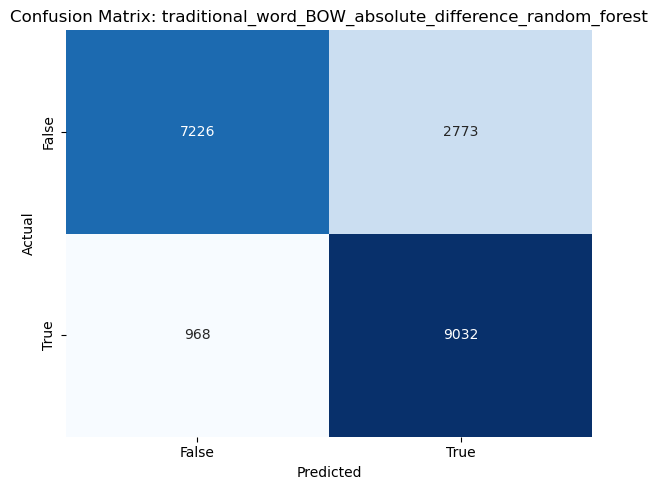

In [54]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [55]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier_name}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
    
    mlflow.log_param("max_features", top_max_features)
    mlflow.log_param("min_df", top_min_df)
    mlflow.log_param("max_df", top_max_df)
    mlflow.log_param("lowercase", top_lowercase)
    mlflow.log_param("binary", top_binary)
                    
    mlflow.log_param("n_estimators", top_n_estimators)
    mlflow.log_param("max_depth", top_max_depth)
    mlflow.log_param("min_samples_split", top_min_samples_split)
    mlflow.log_param("min_samples_leaf", top_min_samples_leaf)
    mlflow.log_param("n_jobs", top_n_jobs)
    mlflow.log_param("random_state", top_random_state)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_traditional_word_BOW_absolute_difference_random_forest at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/74881efa3ce842b39839a877ecdefbd3
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040


# Evaluate model hyperparameters- XGBoost

In [56]:
classifier_name = "xgboost"

In [57]:
xgboost_config = ClassifierConfig(
    classifier_object=XGBClassifier,
    searched_hyperparameters={
        "eta": lambda trial: trial.suggest_float("eta", 0.01, 0.3),
        "max_depth": lambda trial: trial.suggest_int("max_depth", 3, 12),
        "subsample": lambda trial: trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": lambda trial: trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": lambda trial: trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "reg_alpha": lambda trial: trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
    },
    fixed_hyperparameters={
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "n_estimators": 300,     
        "tree_method": "auto", 
        "use_label_encoder": False
    }
)

Set up the study

In [58]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-22 15:21:21,822] A new study created in RDB with name: authorship_verification_traditional_word_BOW_absolute_difference_xgboost


In [ ]:
study.optimize(lambda trial: objective(trial, xgboost_config), n_trials=30)

Fitting vectorizer 

Transforming texts with vectorizer



/opt/conda/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [15:48:26] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Logging results 

Top f1: 85.72

Top accuracy: 86.14

Top precision: 87.36

Top recall: 86.74

Used hyperparameters 

max_features: 50000

min_df: 0.0041026216184919095

max_df: 0.9593352653631143

lowercase: False

binary: False

{'eta': 0.11406775120954082, 'max_depth': 10, 'subsample': 0.8427305559899894, 'colsample_bytree': 0.994409856278268, 'reg_lambda': 0.035686988129282324, 'reg_alpha': 0.016471508465702177, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'n_estimators': 300, 'tree_method': 'auto', 'use_label_encoder': False}


[I 2025-12-22 15:52:33,806] Trial 0 finished with value: 85.72 and parameters: {'max_features': 50000, 'min_df': 0.0041026216184919095, 'max_df': 0.9593352653631143, 'lowercase': False, 'binary': False, 'eta': 0.11406775120954082, 'max_depth': 10, 'subsample': 0.8427305559899894, 'colsample_bytree': 0.994409856278268, 'reg_lambda': 0.035686988129282324, 'reg_alpha': 0.016471508465702177}. Best is trial 0 with value: 85.72.


Fitting vectorizer 

Transforming texts with vectorizer



...

Fitting vectorizer 

Transforming texts with vectorizer



/opt/conda/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [22:41:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Logging results 

Top f1: 86.96

Top accuracy: 87.81

Top precision: 87.81

Top recall: 87.81

Used hyperparameters 

max_features: 20000

min_df: 0.00470666394900943

max_df: 0.8323326772729678

lowercase: False

binary: True

{'eta': 0.18181583368139675, 'max_depth': 8, 'subsample': 0.9153107954629582, 'colsample_bytree': 0.5139756852961117, 'reg_lambda': 8.697575011790988, 'reg_alpha': 0.0014276564938391037, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'n_estimators': 300, 'tree_method': 'auto', 'use_label_encoder': False}


[I 2025-12-22 22:42:30,661] Trial 14 finished with value: 86.96 and parameters: {'max_features': 20000, 'min_df': 0.00470666394900943, 'max_df': 0.8323326772729678, 'lowercase': False, 'binary': True, 'eta': 0.18181583368139675, 'max_depth': 8, 'subsample': 0.9153107954629582, 'colsample_bytree': 0.5139756852961117, 'reg_lambda': 8.697575011790988, 'reg_alpha': 0.0014276564938391037}. Best is trial 14 with value: 86.96.


Fitting vectorizer 

Transforming texts with vectorizer



Save the study insights

In [ ]:
best_trial = study.best_trial
best_params = best_trial.params
best_params.update({
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "n_estimators": 300,     
    "tree_method": "auto", 
    "use_label_encoder": False
})

In [ ]:
trial_results_path = current_dir.parent.parent / "data" / "02_models" / "traditional" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_vectorizer_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_vectorizer.pkl"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [ ]:
trial_rows = []

for trial in study.trials:
    
    if "results" not in trial.user_attrs:
        continue 
        
    metrics = trial.user_attrs["results"]["metrics"]
    hyper_params = trial.user_attrs["results"]["hyperparameters"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in hyper_params.items()},
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

In [ ]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [ ]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - XGBoost

In [ ]:
best_params = {}
trial_results = {}

In [ ]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [ ]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [ ]:
trial_results_df = pd.DataFrame(trial_results)

In [ ]:
top_max_features = best_params["max_features"]
top_min_df = best_params["min_df"]
top_max_df =  best_params["max_df"]
top_lowercase = best_params["lowercase"]
top_binary = best_params["binary"]

top_eta = best_params["eta"]
top_max_depth = best_params["max_depth"]
top_subsample = best_params["subsample"]
top_colsample_bytree = best_params["colsample_bytree"]
top_reg_lambda = best_params["reg_lambda"]
top_reg_alpha = best_params["reg_alpha"]
top_objective = best_params["objective"]
top_eval_metric = best_params["eval_metric"]
top_n_estimators = best_params["n_estimators"]
top_tree_method = best_params["tree_method"]
top_use_label_encoder = best_params["use_label_encoder"]

In [ ]:
print(f"Used hyperparameters \n")
print(f"max_features: {top_max_features}\n")
print(f"min_df: {top_min_df}\n")
print(f"max_df: {top_max_df}\n")
print(f"lowercase: {top_lowercase}\n")
print(f"binary: {top_binary}\n")

print(f"eta: {top_eta}\n")
print(f"max_depth: {top_max_depth}\n")
print(f"subsample: {top_subsample}\n")
print(f"colsample_bytree: {top_colsample_bytree}\n")
print(f"reg_lambda: {top_reg_lambda}\n")
print(f"reg_alpha: {top_reg_alpha}\n")
print(f"objective: {top_objective}\n")
print(f"eval_metric: {top_eval_metric}\n")
print(f"n_estimators: {top_n_estimators}\n")
print(f"tree_method: {top_tree_method}\n")
print(f"use_label_encoder: {top_use_label_encoder}\n")

Reconstruct the best vectorizer

In [ ]:
best_vectorizer = build_bow_vectorizer(
        max_features=top_max_features,
        min_df=top_min_df, 
        max_df=top_max_df,
        lowercase=top_lowercase,
        binary=top_binary
    )

Combine validation and training dataset

In [ ]:
final_train_df = pd.concat(
    [train_data_df, val_data_df],
    ignore_index=True
)

Fit the vectorizer and create features of training and test data

In [ ]:
train_data, test_data = build_bow_features(best_vectorizer, final_train_df, test_data_df)

Compute the absolute differences between the pairs of features in train and test data

In [ ]:
train_data_diff = compute_absolute_difference_features(train_data)
test_data_diff = compute_absolute_difference_features(test_data)

Get the labels for train and test data

In [ ]:
y_train = final_train_df["same"].values
y_test = test_data_df["same"].values

Fit the classifier

In [ ]:
classifier = XGBClassifier(
    eta=top_eta,
    max_depth=top_max_depth,
    subsample=top_subsample,
    colsample_bytree=top_colsample_bytree,
    reg_lambda=top_reg_lambda,
    reg_alpha=top_reg_alpha,
    objective=top_objective,
    eval_metric=top_eval_metric,
    n_estimators=top_n_estimators,
    tree_method=top_tree_method,
    use_label_encoder=top_use_label_encoder
    
)

classifier.fit(train_data_diff, y_train)

Predict the labels for the test data

In [ ]:
y_pred = classifier.predict(test_data_diff)

Evaluate the results of the final classifier

In [ ]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Save the final vectorizer and classifier

In [ ]:
joblib.dump(best_vectorizer, finetuned_vectorizer_path)
joblib.dump(classifier, finetuned_model_path)

Confusion matrix

In [ ]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [ ]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier_name}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
    
    mlflow.log_param("max_features", top_max_features)
    mlflow.log_param("min_df", top_min_df)
    mlflow.log_param("max_df", top_max_df)
    mlflow.log_param("lowercase", top_lowercase)
    mlflow.log_param("binary", top_binary)
                    
    mlflow.log_param("eta", top_eta)
    mlflow.log_param("max_depth", top_max_depth)
    mlflow.log_param("subsample", top_subsample)
    mlflow.log_param("colsample_bytree", top_colsample_bytree)
    mlflow.log_param("reg_lambda", top_reg_lambda)
    mlflow.log_param("reg_alpha", top_reg_alpha)
    mlflow.log_param("objective", top_objective)
    mlflow.log_param("eval_metric", top_eval_metric)
    mlflow.log_param("n_estimators", top_n_estimators)
    mlflow.log_param("tree_method", top_tree_method)
    mlflow.log_param("use_label_encoder", top_use_label_encoder)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")